# CSET Assessment

In [1]:
import os 
import json 
import string
import regex as re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from  matplotlib.ticker import PercentFormatter
from collections import Counter, defaultdict
from datetime import datetime

from utils import read_word_list, get_category_names

In [2]:
sns.set_theme(style='darkgrid', context='paper')

In [3]:
papers = []
with open(os.path.join('..', 'data', 'arxiv_data.jsonl'), 'r') as file:
    for line in file: 
        papers.append(json.loads(line))

In [4]:
cs_category_map = get_category_names('https://arxiv.org/archive/cs')

## Question 1: Identifying papers about agentic AI

### Question 1.A

In [5]:
# load in pre-defined list of words
narrow_word_list = read_word_list(os.path.join('..', 'word_lists', 'agentic_ai_narrow.txt'))
broad_word_list = read_word_list(os.path.join('..', 'word_lists', 'agentic_ai_broad.txt'))

# remove punctuation, excluding hyphen 
to_remove = set(string.punctuation) - set('-')

In [6]:
narrow_matches = set()
broad_matches = set()

# compiling regular expressions outside of loop to improve runtime & remove redundant operations
narrow_regex_patterns = [re.compile(f'(?:\\b)?{word}(:?\\b)?') for word in narrow_word_list]
broad_regex_patterns = [re.compile(f'(?:\\b)?{word}(:?\\b)?') for word in broad_word_list]

for paper in papers:
    title = paper.get('title', '').lower().strip()
    abstract = paper.get('abstract', '').lower().strip()
    paper_id = paper.get('id')

    for char in to_remove: 
        title = title.replace(char, '')
        abstract = abstract.replace(char, '')

    for pattern in narrow_regex_patterns:
        if pattern.search(title) or pattern.search(abstract):
            narrow_matches.add(paper_id)
            # only need to match one of the patterns to count 
            # cut down run time by ending loop if a match is already found
            break

    for pattern in broad_regex_patterns:
        if pattern.search(title) or pattern.search(abstract):
            broad_matches.add(paper_id)
            # only need to match one of the patterns to count 
            # cut down run time by ending loop if a match is already found
            break

In [7]:
all_matches = broad_matches | narrow_matches

In [8]:
len(narrow_matches), len(broad_matches)

(2969, 5278)

In [9]:
len(broad_matches - narrow_matches)

4618

In [10]:
len(all_matches)

7587

### Question 1.B

In [11]:
cs_ma_papers = set([paper.get('id') for paper in papers if 'cs.ma' in paper.get('categories').lower()])

In [12]:
only_in_cs_ma = cs_ma_papers - all_matches
shared = cs_ma_papers.intersection(all_matches)

In [13]:
len(only_in_cs_ma), len(shared)

(5516, 1461)

What repositories were relevant papers in? 

In [14]:
repository_counts = Counter()

for paper in papers: 
    if paper.get('id') in broad_matches:
        repos = paper.get('categories_split')

        for repo in repos:
            repository_counts.update([cs_category_map.get(repo, repo)])

In [15]:
repository_counts.most_common(10)

[('Artificial Intelligence', 4238),
 ('Multiagent Systems', 1900),
 ('Computation and Language', 1778),
 ('Machine Learning', 1695),
 ('Systems and Control', 897),
 ('eess.SY', 821),
 ('Robotics', 736),
 ('Cryptography and Security', 519),
 ('Software Engineering', 509),
 ('math.OC', 478)]

In [16]:
# a small number of ids (e.g. 2601.16296) have multiple created dates
# we will consider the first created date to be the source of truth
first_submission = {}

for paper in papers: 
    paper_id = paper['id']
    created = datetime.fromisoformat(paper.get('created'))

    if paper_id not in first_submission or created < first_submission[paper_id]:
        first_submission[paper_id] = created

In [17]:
publications_by_year = defaultdict(set)
agentic_ai_publications_by_year = defaultdict(set)

for paper_id, created in list(first_submission.items()):
    year = created.year
    publications_by_year[year].add(paper_id)

    if paper_id in all_matches:
        agentic_ai_publications_by_year[year].add(paper_id)


In [18]:
pub_stats = []

for year in list(publications_by_year.keys()):
    agentic_ai_pubs = len(agentic_ai_publications_by_year.get(year, set()))
    overall_pubs = len(publications_by_year.get(year, set()))

    pub_stats.append([year, agentic_ai_pubs, overall_pubs, (agentic_ai_pubs / overall_pubs) * 100])

In [19]:
pub_df = pd.DataFrame(pub_stats, columns=['year', 'agentic_ai_pubs', 'all_pubs', 'pct_agentic_ai'])

In [20]:
pub_df.sort_values(by='year', ascending=True)

,year,agentic_ai_pubs,all_pubs,pct_agentic_ai
36,1989,0,2,0.000000
37,1990,0,9,0.000000
35,1991,0,112,0.000000
34,1992,0,944,0.000000
30,1993,0,2078,0.000000
33,1994,1,2938,0.034037
29,1995,0,3852,0.000000
23,1996,0,4731,0.000000
24,1997,0,5884,0.000000
28,1998,0,7319,0.000000


Visualization to show change over time - I am a visual person and find this helpful for interpretting data

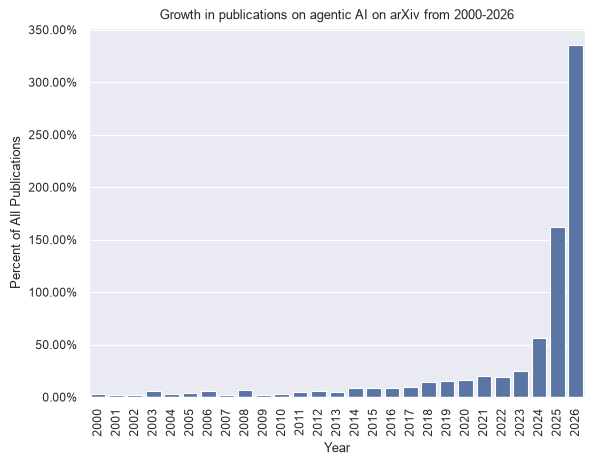

In [21]:
f = sns.barplot(pub_df[(pub_df['year'] >= 2000) & (pub_df['year'] <= 2026)], x='year', y='pct_agentic_ai')
f.set(title='Growth in publications on agentic AI on arXiv from 2000-2026', 
      xlabel='Year', 
      ylabel='Percent of All Publications')

_ = plt.xticks(rotation=90)
_ = f.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=2))